# PowerFactory to OpenModelica 0–100% 2 MW Workflow

Converted from the uploaded Python script. Run cells in order. Edit paths in Cell 1 before running.


In [3]:
PF_ROOT = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP4"
PROFILE_ZIP_PATH = Path(r"C:\Users\ADMIN\Desktop\New folder\New folder\data (2).zip")
PF_USER = "ADMIN"

In [4]:
from pathlib import Path

In [5]:
# =========================================================
# CELL 1: Imports and editable paths
# =========================================================
from pathlib import Path
import io
import zipfile
import os
import sys
import re
import time
import traceback
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# EDIT THESE IF NEEDED
# -----------------------------
PF_ROOT = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP4"
PF_BIN  = str(Path(PF_ROOT) / "Bin")


def resolve_pf_python_dir(pf_root):
    python_root = Path(pf_root) / "Python"
    requested = python_root / f"{sys.version_info.major}.{sys.version_info.minor}"
    if requested.exists():
        return str(requested)

    available = sorted(
        [p for p in python_root.iterdir() if p.is_dir() and re.fullmatch(r"\d+\.\d+", p.name)],
        key=lambda p: tuple(int(x) for x in p.name.split("."))
    ) if python_root.exists() else []

    supported = ", ".join(p.name for p in available) if available else "none"
    raise RuntimeError(
        f"PowerFactory Python bindings for Python {sys.version_info.major}.{sys.version_info.minor} "
        f"were not found under {python_root}. Available versions: {supported}. "
        "Run the script with a supported Python version or update PF_ROOT."
    )


PF_PY = resolve_pf_python_dir(PF_ROOT)


def resolve_openmodelica_home():
    env_home = os.environ.get("OPENMODELICAHOME", "").strip().strip('"')
    if env_home:
        env_path = Path(env_home)
        if (env_path / "bin" / "omc.exe").exists():
            return env_path

    search_roots = [Path(r"C:\Program Files"), Path(r"C:\Program Files (x86)")]
    candidates = []
    for root in search_roots:
        if root.exists():
            candidates.extend(
                path for path in root.glob("OpenModelica*")
                if (path / "bin" / "omc.exe").exists()
            )

    if not candidates:
        raise RuntimeError(
            "Could not locate an OpenModelica installation. Set OPENMODELICAHOME or install OpenModelica."
        )

    return sorted(candidates, key=lambda p: p.name, reverse=True)[0]

PROJECT_NAME = "IEEE33_RE"
STUDYCASE_NAME = "Study Case"
PF_USER = "ADMIN"

if (Path.home() / "Desktop").exists():
    BASE_DIR = Path.home() / "Desktop" / "ms-project_pf_to_om_2MW"
elif (Path.home() / "OneDrive" / "Desktop").exists():
    BASE_DIR = Path.home() / "OneDrive" / "Desktop" / "ms-project_pf_to_om_2MW"
else:
    BASE_DIR = Path.home() / "Documents" / "ms-project_pf_to_om_2MW"

BASE_DIR.mkdir(parents=True, exist_ok=True)

# Full path to your existing zip with hourly profiles
PROFILE_ZIP_PATH = Path(r"C:\Users\ADMIN\Desktop\New folder\New folder\data (2).zip")

# -----------------------------
# RUN MODE
# -----------------------------
# FAST_DEBUG = True  -> quick test: 75% and 100%, severe only
# FAST_DEBUG = False -> full paper run: 0,10,25,50,75,100 and mild/moderate/severe
FAST_DEBUG = True

FULL_PENETRATIONS = [0, 10, 25, 50, 75, 100]
FULL_SCENARIOS = ["mild", "moderate", "severe"]

if FAST_DEBUG:
    PENETRATIONS = [0,10,25,50,75, 100]
    SCENARIOS = ["mild", "moderate","severe"]
else:
    PENETRATIONS = FULL_PENETRATIONS
    SCENARIOS = FULL_SCENARIOS

# Optional: restrict hours during debugging only, e.g. [12, 18]
PF_DEBUG_HOURS = None

T_EVENT = 1.0
BESS_MW_DYNAMIC = 2.0

PV_NAMES = ["PV_Bus6", "PV_Bus18", "PV_Bus30"]
WIND_NAMES = ["WIND_Bus14", "WIND_Bus25"]
LOAD_NAMES = [f"Load_Bus{i}" for i in range(2, 34)]
BESS_NAME = "BESS_Bus33"
BESS_PRE_DISPATCH_MW = 0.0

MODEL_MO_PATH = BASE_DIR / "ThesisFreqCasesExpanded2MW.mo"

warnings.filterwarnings(
    "once",
    message="invalid value encountered in divide",
    category=RuntimeWarning
)

print("BASE_DIR:", BASE_DIR)
print("PROFILE_ZIP_PATH exists?:", PROFILE_ZIP_PATH.exists())
print("MODEL_MO_PATH:", MODEL_MO_PATH)
print("FAST_DEBUG:", FAST_DEBUG)
print("PENETRATIONS:", PENETRATIONS)
print("SCENARIOS:", SCENARIOS)


BASE_DIR: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW
PROFILE_ZIP_PATH exists?: True
MODEL_MO_PATH: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\ThesisFreqCasesExpanded2MW.mo
FAST_DEBUG: True
PENETRATIONS: [0, 10, 25, 50, 75, 100]
SCENARIOS: ['mild', 'moderate', 'severe']


## CELL 1: Imports and editable paths


## CELL 2: Load hourly profiles from the existing zip


In [6]:
# =========================================================
# CELL 2: Load hourly profiles from the existing zip
# =========================================================
if not PROFILE_ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Could not find profile zip:\n{PROFILE_ZIP_PATH}\n\n"
        "Copy 'data (2).zip' into BASE_DIR or edit PROFILE_ZIP_PATH."
    )

def read_csv_from_zip(zip_path, member_name):
    with zipfile.ZipFile(zip_path, "r") as z:
        return pd.read_csv(io.BytesIO(z.read(member_name)))

profile_df = read_csv_from_zip(PROFILE_ZIP_PATH, "data/stage3_timeseries/stage3_timeseries_summary.csv")
profile_df.columns = [c.strip() for c in profile_df.columns]

required_cols = ["hour", "load_scale", "pv_availability", "wind_availability", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]
missing = [c for c in required_cols if c not in profile_df.columns]
if missing:
    raise ValueError(f"Missing required columns in stage3_timeseries_summary.csv: {missing}")

for c in required_cols:
    profile_df[c] = pd.to_numeric(profile_df[c], errors="coerce")

profile_df = profile_df.dropna(subset=required_cols).copy()
profile_df = profile_df.sort_values("hour").reset_index(drop=True)

PEAK_LOAD_MW = float(profile_df["P_load_scaled_MW"].max())
pv_ref_installed = float((profile_df.loc[profile_df["pv_availability"] > 1e-6, "P_pv_MW"] /
                          profile_df.loc[profile_df["pv_availability"] > 1e-6, "pv_availability"]).max())
wind_ref_installed = float((profile_df.loc[profile_df["wind_availability"] > 1e-6, "P_wind_MW"] /
                            profile_df.loc[profile_df["wind_availability"] > 1e-6, "wind_availability"]).max())
REFERENCE_TOTAL_PEN = 75.0

print("PEAK_LOAD_MW:", PEAK_LOAD_MW)
print("Estimated PV installed at 75% case (MW):", pv_ref_installed)
print("Estimated Wind installed at 75% case (MW):", wind_ref_installed)
print(profile_df.head())


PEAK_LOAD_MW: 2.0066470101039418
Estimated PV installed at 75% case (MW): 1.0534896803045692
Estimated Wind installed at 75% case (MW): 0.4514955772733868
   hour  load_scale  pv_availability  wind_availability  P_load_scaled_MW  \
0     0    0.512236              0.0           0.761803          1.028229   
1     1    0.500343              0.0           0.786716          1.004355   
2     2    0.505463              0.0           0.798904          1.014634   
3     3    0.527248              0.0           0.797538          1.058364   
4     4    0.564214              0.0           0.782709          1.132566   

   P_pv_MW  P_wind_MW   Vmin_pu   Vmax_pu  max_line_loading_pct max_line_name  \
0      0.0   0.176244  0.994817  1.049409              8.485616         L_2_3   
1      0.0   0.177782  0.994953  1.050001              8.558682         L_2_3   
2      0.0   0.182384  0.994895  1.049865              8.548889         L_2_3   
3      0.0   0.189919  0.994648  1.049013              8.4

In [7]:
# =========================================================
# CELL 1: Imports, PowerFactory path, and general settings
# =========================================================
import os
import sys
import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# EDIT THESE POWERFACTORY PATHS
# -----------------------------
PF_ROOT = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP4"
PF_PY   = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP4\Python\3.10"
PF_BIN  = PF_ROOT + r"\Bin"

# Add PowerFactory Python API
if PF_PY not in sys.path:
    sys.path.append(PF_PY)

# DLL search paths
os.environ["PATH"] = PF_ROOT + ";" + PF_BIN + ";" + os.environ["PATH"]
try:
    os.add_dll_directory(PF_ROOT)
    os.add_dll_directory(PF_BIN)
except Exception:
    pass

import powerfactory as pf



## CELL 3: Connect to PowerFactory engine mode


In [8]:
# =========================================================
# CELL 2: Connect to PowerFactory engine mode
# =========================================================
# IMPORTANT:
# Run this in a fresh kernel.
# If PowerFactory GUI is open, close it before using GetApplicationExt.

app = pf.GetApplicationExt("ADMIN")   # remove "ADMIN" if needed on your machine
if app is None:
    raise RuntimeError(
        "Could not start PowerFactory engine mode. "
        "Close PowerFactory GUI and try again."
    )

app.ClearOutputWindow()
app.PrintPlain("Connected to PowerFactory engine mode.")
print("Connected to PowerFactory engine mode.")

Connected to PowerFactory engine mode.


## CELL 4: Activate project/study case and helper functions


In [9]:
# =========================================================
# CELL 4: Activate project/study case and helper functions
# =========================================================
rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    raise RuntimeError(f"Could not activate project: {PROJECT_NAME}")

study = app.GetProjectFolder("study")
cases = study.GetContents("*.IntCase")
print("Available study cases:", [c.loc_name for c in cases])

target_case = None
for c in cases:
    if c.loc_name == STUDYCASE_NAME:
        target_case = c
        break
if target_case is None:
    raise RuntimeError(f"Study case '{STUDYCASE_NAME}' not found.")

target_case.Activate()
print("Activated study case:", target_case.loc_name)

def get_from_study_case(class_name):
    obj = app.GetFromStudyCase(class_name)
    if obj is None:
        raise RuntimeError(f"Could not get {class_name} from active study case")
    return obj

def find_unique(name):
    objs = app.GetCalcRelevantObjects(name + ".*")
    if not objs:
        raise RuntimeError(f"Object not found: {name}")
    return objs[0]

def find_many(name_list):
    return [find_unique(nm) for nm in name_list]

def safe_get(obj, attr_names, default=np.nan):
    for attr in attr_names:
        try:
            val = obj.GetAttribute(attr)
            if val is not None:
                try:
                    return float(val)
                except Exception:
                    return val
        except Exception:
            pass
    return default

def safe_set(obj, attr_names, value):
    for attr in attr_names:
        try:
            obj.SetAttribute(attr, value)
            return True
        except Exception:
            pass
    return False

pv_objs = find_many(PV_NAMES)
wind_objs = find_many(WIND_NAMES)
load_objs = find_many(LOAD_NAMES)
bess_obj = find_unique(BESS_NAME)

print("PV objects:", [o.loc_name for o in pv_objs])
print("Wind objects:", [o.loc_name for o in wind_objs])
print("Load count:", len(load_objs))
print("BESS object:", bess_obj.loc_name)

try:
    bess_obj.outserv = 0
except Exception:
    pass

load_base = {}
for obj in load_objs:
    p0 = safe_get(obj, ["plini", "pgini", "Pnom", "m:P"], 0.0)
    q0 = safe_get(obj, ["qlini", "qgini", "Qnom", "m:Q"], 0.0)
    load_base[obj.loc_name] = (float(p0), float(q0))

def shares_from_pgini(objs):
    vals = []
    for o in objs:
        vals.append(max(0.0, safe_get(o, ["pgini", "Psetp", "sgn"], 0.0)))
    s = sum(vals)
    if s > 1e-9:
        return [v / s for v in vals]
    return [1.0 / len(objs)] * len(objs)

pv_shares = shares_from_pgini(pv_objs)
wind_shares = shares_from_pgini(wind_objs)

print("PV shares:", pv_shares)
print("Wind shares:", wind_shares)


ActivateProject return: 0
Available study cases: ['Study Case']
Activated study case: Study Case
PV objects: ['PV_Bus6', 'PV_Bus18', 'PV_Bus30']
Wind objects: ['WIND_Bus14', 'WIND_Bus25']
Load count: 32
BESS object: BESS_Bus33
PV shares: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Wind shares: [0.5, 0.5]


## CELL 5: PowerFactory load-flow helpers


In [10]:
# =========================================================
# CELL 5: PowerFactory load-flow helpers
# =========================================================
def set_load_scale(scale):
    for obj in load_objs:
        p0, q0 = load_base[obj.loc_name]
        safe_set(obj, ["plini"], p0 * scale)
        safe_set(obj, ["qlini"], q0 * scale)

def set_generation_for_penetration(pen_pct, pv_availability, wind_availability, bess_mw=0.0):
    scale = pen_pct / REFERENCE_TOTAL_PEN if REFERENCE_TOTAL_PEN > 0 else 0.0
    pv_total = pv_ref_installed * scale * pv_availability
    wind_total = wind_ref_installed * scale * wind_availability

    for obj, sh in zip(pv_objs, pv_shares):
        safe_set(obj, ["pgini"], pv_total * sh)
        safe_set(obj, ["qgini"], 0.0)
        try:
            obj.outserv = 0 if pv_total > 0 else 1
        except Exception:
            pass

    for obj, sh in zip(wind_objs, wind_shares):
        safe_set(obj, ["pgini"], wind_total * sh)
        safe_set(obj, ["qgini"], 0.0)
        try:
            obj.outserv = 0 if wind_total > 0 else 1
        except Exception:
            pass

    safe_set(bess_obj, ["pgini"], bess_mw)
    safe_set(bess_obj, ["qgini"], 0.0)
    try:
        bess_obj.outserv = 0
    except Exception:
        pass

def run_load_flow():
    ldf = get_from_study_case("ComLdf")
    ierr = ldf.Execute()
    if ierr != 0:
        raise RuntimeError(f"Load flow failed with code {ierr}")

def collect_snapshot_metrics():
    terms = [o for o in app.GetCalcRelevantObjects("*.ElmTerm") if safe_get(o, ["outserv"], 0) == 0]
    v_vals = [safe_get(t, ["m:u", "m:U", "m:Ul"], np.nan) for t in terms]
    v_vals = [v for v in v_vals if pd.notna(v)]

    line_objs = [o for o in app.GetCalcRelevantObjects("*.ElmLne") if safe_get(o, ["outserv"], 0) == 0]
    tr_objs = [o for o in app.GetCalcRelevantObjects("*.ElmTr2") if safe_get(o, ["outserv"], 0) == 0]

    loading_list = []
    loss_total = 0.0

    def branch_loss_mw(obj):
        for attrs in [["c:Ploss"], ["m:Ploss"], ["c:ploss"], ["m:ploss"]]:
            val = safe_get(obj, attrs, np.nan)
            if pd.notna(val):
                return abs(float(val))
        p1 = safe_get(obj, ["m:P:bus1", "c:P:bus1"], np.nan)
        p2 = safe_get(obj, ["m:P:bus2", "c:P:bus2"], np.nan)
        if pd.notna(p1) and pd.notna(p2):
            return abs(float(p1) + float(p2))
        return 0.0

    for obj in line_objs + tr_objs:
        ld = safe_get(obj, ["c:loading", "m:loading", "c:loading1"], np.nan)
        if pd.notna(ld):
            loading_list.append((obj.loc_name, float(ld)))
        loss_total += branch_loss_mw(obj)

    vmax = max(v_vals) if v_vals else np.nan
    vmin = min(v_vals) if v_vals else np.nan
    if loading_list:
        idx = int(np.argmax([x[1] for x in loading_list]))
        max_loading_name, max_loading = loading_list[idx]
    else:
        max_loading_name, max_loading = "", np.nan

    return {
        "Vmin_pu": vmin,
        "Vmax_pu": vmax,
        "max_line_loading_pct": max_loading,
        "max_line_name": max_loading_name,
        "losses_MW": loss_total
    }


## CELL 6: PowerFactory steady-state metrics for 0,10,25,50,75,100


In [11]:
# =========================================================
# CELL 6: PowerFactory steady-state metrics for 0,10,25,50,75,100
# =========================================================
steady_rows = []
for pen in PENETRATIONS:
    set_load_scale(1.0)
    set_generation_for_penetration(pen, pv_availability=1.0, wind_availability=1.0, bess_mw=BESS_PRE_DISPATCH_MW)
    run_load_flow()
    m = collect_snapshot_metrics()
    m["Penetration (%)"] = pen
    steady_rows.append(m)

pf_steady_df = pd.DataFrame(steady_rows)[[
    "Penetration (%)", "Vmin_pu", "Vmax_pu", "losses_MW", "max_line_loading_pct", "max_line_name"
]]
print(pf_steady_df)
pf_steady_df.to_csv(BASE_DIR / "pf_steady_state_0_100.csv", index=False)
print("Saved:", BASE_DIR / "pf_steady_state_0_100.csv")


   Penetration (%)   Vmin_pu   Vmax_pu  losses_MW  max_line_loading_pct  \
0                0  0.999867  1.029499   0.024608             11.689813   
1               10  0.999825  1.035107   0.032092             13.623356   
2               25  0.999748  1.043380   0.045668             16.500236   
3               50  0.999585  1.056843   0.074360             21.238478   
4               75  0.999380  1.069916   0.110293             25.909169   
5              100  0.999134  1.082624   0.153120             30.516729   

  max_line_name  
0   TR_33_12p66  
1   TR_33_12p66  
2   TR_33_12p66  
3   TR_33_12p66  
4   TR_33_12p66  
5   TR_33_12p66  
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_steady_state_0_100.csv


## CELL 7: PowerFactory 24 h time-series for all six penetration levels


In [12]:
# =========================================================
# CELL 7: PowerFactory 24 h time-series for all six penetration levels
# =========================================================
timeseries_all = {}

for pen in PENETRATIONS:
    rows = []
    profile_iter = profile_df if PF_DEBUG_HOURS is None else profile_df[profile_df["hour"].isin(PF_DEBUG_HOURS)].copy()

    for _, r in profile_iter.iterrows():
        hr = int(r["hour"])
        load_scale = float(r["load_scale"])
        pv_av = float(r["pv_availability"])
        wind_av = float(r["wind_availability"])

        set_load_scale(load_scale)
        set_generation_for_penetration(pen, pv_availability=pv_av, wind_availability=wind_av, bess_mw=BESS_PRE_DISPATCH_MW)
        run_load_flow()
        m = collect_snapshot_metrics()

        scale = pen / REFERENCE_TOTAL_PEN if REFERENCE_TOTAL_PEN > 0 else 0.0
        p_pv = pv_ref_installed * scale * pv_av
        p_wind = wind_ref_installed * scale * wind_av

        rows.append({
            "hour": hr,
            "load_scale": load_scale,
            "pv_availability": pv_av,
            "wind_availability": wind_av,
            "P_load_scaled_MW": PEAK_LOAD_MW * load_scale,
            "P_pv_MW": p_pv,
            "P_wind_MW": p_wind,
            "Vmin_pu": m["Vmin_pu"],
            "Vmax_pu": m["Vmax_pu"],
            "max_line_loading_pct": m["max_line_loading_pct"],
            "max_line_name": m["max_line_name"],
            "losses_MW": m["losses_MW"]
        })

    df_pen = pd.DataFrame(rows).sort_values("hour").reset_index(drop=True)
    timeseries_all[pen] = df_pen
    out_csv = BASE_DIR / f"pf_timeseries_pen_{pen}.csv"
    df_pen.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

ts_combined = pd.concat(
    [df.assign(**{"Penetration (%)": pen}) for pen, df in timeseries_all.items()],
    ignore_index=True
)
ts_combined.to_csv(BASE_DIR / "pf_timeseries_all_penetrations_0_100.csv", index=False)
print("Saved:", BASE_DIR / "pf_timeseries_all_penetrations_0_100.csv")


Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_timeseries_pen_0.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_timeseries_pen_10.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_timeseries_pen_25.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_timeseries_pen_50.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_timeseries_pen_75.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_timeseries_pen_100.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\pf_timeseries_all_penetrations_0_100.csv


## CELL 8: OpenModelica model file (2 MW study)


In [13]:
# =========================================================
# CELL 8: OpenModelica model file (2 MW study) - TUNED
# =========================================================
modelica_code = '''
within ;
package ThesisFreqCasesExpanded2MW

  partial model BaseFreqCase
    parameter Real f0 = 50 "Nominal frequency (Hz)";
    parameter Real H = 4.0 "Virtual inertia constant (s)";
    parameter Real D = 1.0 "Damping coefficient (pu/Hz)";
    parameter Real R = 0.06 "Droop constant (Hz/pu)";
    parameter Real deadband = 0.005 "Deadband (Hz)";

    parameter Real T_droop = 0.40 "Droop time constant (s)";
    parameter Real T_ffr   = 0.01 "FFR time constant (s)";

    parameter Real PmaxDroop = 0.20 "Droop support cap (pu)";
    parameter Real PmaxFFR = 0.20 "FFR support cap (pu)";
    parameter Real PmaxTotal = 0.30 "Total support cap (pu)";
    parameter Real ffrGain = 3.00 "FFR gain (pu/Hz)";
    parameter Real ffrDuration = 2.0 "FFR duration (s)";

    parameter Real tEvent = 1.0 "Event time (s)";
    parameter Real dPstep = -0.10 "Disturbance in pu";

    Real df(start=0, fixed=true) "Frequency deviation (Hz)";
    Real fHz "Frequency (Hz)";
    Real rocofHzps "RoCoF (Hz/s)";

    Real Pdist "Disturbance power (pu)";
    Real Pdroop "Droop support (pu)";
    Real Pffr "FFR support (pu)";
    Real Psupport "Total support (pu)";

  protected
    Real df_droop(start=0, fixed=true);
    Real df_ffr(start=0, fixed=true);
    Real Pdroop_raw;
    Real Pffr_raw;

  equation
    Pdist = if time < tEvent then 0 else dPstep;

    der(df_droop) = (df - df_droop) / T_droop;
    der(df_ffr)   = (df - df_ffr) / T_ffr;

    Pdroop_raw = if noEvent(abs(df_droop) <= deadband) then 0 else -df_droop / R;
    Pdroop = min(max(Pdroop_raw, -PmaxDroop), PmaxDroop);

    Pffr_raw = if noEvent(time < tEvent or time > tEvent + ffrDuration or abs(df_ffr) <= deadband)
               then 0 else -ffrGain * df_ffr;
    Pffr = min(max(Pffr_raw, -PmaxFFR), PmaxFFR);

    Psupport = min(max(Pdroop + Pffr, -PmaxTotal), PmaxTotal);

    der(df) = (f0 / (2 * H)) * (Pdist + Psupport - D * df);

    fHz = f0 + df;
    rocofHzps = der(fHz);

    annotation(experiment(StopTime=8, Interval=0.02));
  end BaseFreqCase;

  model BaseCase
    extends BaseFreqCase(
      PmaxDroop=0.0,
      PmaxFFR=0.0,
      PmaxTotal=0.0,
      ffrGain=0.0,
      ffrDuration=0.0
    );
  end BaseCase;

  model DroopCase
    extends BaseFreqCase(
      PmaxFFR=0.0,
      ffrGain=0.0,
      ffrDuration=0.0
    );
  end DroopCase;

  model DroopFFRCase
    extends BaseFreqCase;
  end DroopFFRCase;

end ThesisFreqCasesExpanded2MW;
'''

MODEL_MO_PATH = BASE_DIR / "ThesisFreqCasesExpanded2MW.mo"
with open(MODEL_MO_PATH, "w", encoding="utf-8") as f:
    f.write(modelica_code)

print("Wrote:", MODEL_MO_PATH)

Wrote: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\ThesisFreqCasesExpanded2MW.mo


## CELL 9: Connect to OpenModelica


In [14]:
# =========================================================
# CELL 9: Connect to OpenModelica
# =========================================================
OPENMODELICA_HOME = resolve_openmodelica_home()
OPENMODELICA_BIN = str(OPENMODELICA_HOME / "bin")

os.environ["OPENMODELICAHOME"] = str(OPENMODELICA_HOME)
if OPENMODELICA_BIN not in os.environ.get("PATH", ""):
    os.environ["PATH"] = OPENMODELICA_BIN + ";" + os.environ.get("PATH", "")
try:
    os.add_dll_directory(OPENMODELICA_BIN)
except Exception:
    pass

try:
    from OMPython import OMCSessionZMQ
except ImportError as exc:
    raise RuntimeError(
        "OMPython is not installed for the active Python interpreter. "
        "Install it with 'python -m pip install OMPython' or run the script in an environment where it is available."
    ) from exc

omc = OMCSessionZMQ()

base_dir_om = BASE_DIR.as_posix()
model_mo_path_om = MODEL_MO_PATH.as_posix()

print("OpenModelica version:", omc.sendExpression("getVersion()"))
print("loadModel(Modelica):", omc.sendExpression("loadModel(Modelica)"))
print("cd(BASE_DIR):", omc.sendExpression(f'cd("{base_dir_om}")'))
print("loadFile(model):", omc.sendExpression(f'loadFile("{model_mo_path_om}")'))
print("OMC errors:", omc.sendExpression("getErrorString()"))


OpenModelica version: OpenModelica v1.26.2 (64-bit)


Result of 'getErrorString()' cannot be parsed!


loadModel(Modelica): True
cd(BASE_DIR): C:/Users/ADMIN/Desktop/ms-project_pf_to_om_2MW
loadFile(model): True
OMC errors: ""



## CELL 10: SAFE + FASTER OpenModelica helpers


In [15]:
# =========================================================
# CELL 10: SAFE + FASTER OpenModelica helpers
# =========================================================
def simulate_openmodelica_model(omc, model_name, stop_time=6.0, step_size=0.02, parameter_overrides=None):
    simflags = ""
    if parameter_overrides:
        override_str = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        simflags = f', simflags="-override={override_str}"'

    n_intervals = int(round(stop_time / step_size))
    cmd = f'simulate({model_name}, stopTime={stop_time}, numberOfIntervals={n_intervals}, outputFormat="csv"{simflags})'
    sim_out = omc.sendExpression(cmd)

    if isinstance(sim_out, dict):
        res = sim_out.get("resultFile", "")
        if res and os.path.exists(res):
            return Path(res), sim_out
        print("OMC error:", omc.sendExpression("getErrorString()"))
        raise RuntimeError(f"Simulation failed for {model_name}")

    txt = str(sim_out)
    m = re.search(r'resultFile\s*=\s*"([^"]+)"', txt)
    if m and os.path.exists(m.group(1)):
        return Path(m.group(1)), sim_out

    print("OMC error:", omc.sendExpression("getErrorString()"))
    raise RuntimeError(f"Could not parse resultFile for {model_name}. Raw: {txt}")


def load_frequency_csv(result_csv):
    df = pd.read_csv(result_csv)

    needed = ["time", "fHz", "rocofHzps"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns {missing} in result file: {result_csv}")

    for c in needed:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["time", "fHz"]).copy()
    df = df.sort_values("time").reset_index(drop=True)

    t = df["time"].to_numpy(dtype=float)
    keep = np.concatenate(([True], np.diff(t) > 0))
    df = df.loc[keep].reset_index(drop=True)

    return (
        df["time"].to_numpy(dtype=float),
        df["fHz"].to_numpy(dtype=float),
        df["rocofHzps"].to_numpy(dtype=float),
    )


def compute_frequency_metrics(t, f_hz, rocof_trace=None, t_event=1.0, rocof_window=0.10, eps=0.01):
    t = np.asarray(t, dtype=float)
    f = np.asarray(f_hz, dtype=float)

    mask = np.isfinite(t) & np.isfinite(f)
    t = t[mask]
    f = f[mask]

    if rocof_trace is not None:
        rocof_trace = np.asarray(rocof_trace, dtype=float)
        if len(rocof_trace) == len(mask):
            rocof_trace = rocof_trace[mask]
        else:
            rocof_trace = None

    if len(t) < 2:
        return np.nan, np.nan, np.nan

    rocof = np.nan
    if rocof_trace is not None and len(rocof_trace) == len(t):
        rm = np.isfinite(rocof_trace) & (t >= t_event) & (t <= t_event + rocof_window)
        if np.any(rm):
            rocof = float(np.max(np.abs(rocof_trace[rm])))

    if not np.isfinite(rocof):
        dt = np.diff(t)
        df = np.diff(f)
        valid = dt > 0
        if np.any(valid):
            dfdt = df[valid] / dt[valid]
            tmid = 0.5 * (t[1:] + t[:-1])[valid]
            rm = (tmid >= t_event) & (tmid <= t_event + rocof_window)
            rocof = float(np.max(np.abs(dfdt[rm]))) if np.any(rm) else float(np.max(np.abs(dfdt)))
        else:
            rocof = np.nan

    nadir = float(np.min(f))
    f_final = float(f[-1])

    within = np.abs(f - f_final) <= eps
    settling = np.nan
    for i in range(len(t)):
        if t[i] >= t_event and within[i] and np.all(within[i:]):
            settling = float(t[i])
            break

    return rocof, nadir, settling


## CELL 11: Extract mild / moderate / severe events from real PowerFactory exports


In [16]:
# =========================================================
# CELL 11: Extract mild / moderate / severe events from real PowerFactory exports
# =========================================================

S_BASE_MVA = 10.0  # Dynamic reduced-order frequency-model base

def nearest_value(series, target):
    s = pd.Series(series).dropna()
    if len(s) == 0:
        return np.nan, None
    idx = (s - target).abs().idxmin()
    return float(s.loc[idx]), idx


scenario_rows = []

for pen, df_pen in timeseries_all.items():
    p_res = df_pen["P_pv_MW"] + df_pen["P_wind_MW"]
    dP = p_res.diff()
    neg = (-dP[dP < 0]).dropna()

    if len(neg) == 0:
        for scen in SCENARIOS:
            scenario_rows.append({
                "Penetration (%)": pen,
                "Scenario": scen,
                "Representative hour": np.nan,
                "DeltaP_MW": 0.0,
                "dPstep_feeder_pu": 0.0,
                "dPstep_dyn_pu": 0.0
            })
        continue

    q50 = float(np.quantile(neg, 0.50))
    q75 = float(np.quantile(neg, 0.75))
    q100 = float(np.max(neg))

    target_lookup = {
        "mild": q50,
        "moderate": q75,
        "severe": q100
    }

    for scen in SCENARIOS:
        target = target_lookup[scen]
        mag_mw, idx = nearest_value(neg, target)
        rep_hour = float(df_pen.loc[idx, "hour"]) if idx is not None else np.nan

        scenario_rows.append({
            "Penetration (%)": pen,
            "Scenario": scen,
            "Representative hour": rep_hour,
            "DeltaP_MW": mag_mw,

            # Feeder-base value used only for screening/reporting
            "dPstep_feeder_pu": -(mag_mw / PEAK_LOAD_MW),

            # Correct dynamic-model input on 10 MVA base
            "dPstep_dyn_pu": -(mag_mw / S_BASE_MVA)
        })


scenario_event_df = pd.DataFrame(scenario_rows)

print(scenario_event_df)

scenario_event_df.to_csv(
    BASE_DIR / "scenario_event_mapping_from_real_pf_exports.csv",
    index=False
)

print("Saved:", BASE_DIR / "scenario_event_mapping_from_real_pf_exports.csv")


# =========================================================
# BESS sizing helpers
# =========================================================

def bess_limits_from_mw(bess_mw, s_base_mw, droop_share=0.60, ffr_share=0.40):
    bess_pu = bess_mw / s_base_mw

    return {
        "BESS_MW": bess_mw,
        "BESS_PU": bess_pu,
        "PmaxDroop": droop_share * bess_pu,
        "PmaxFFR": ffr_share * bess_pu,
        "PmaxTotal": bess_pu
    }


# IMPORTANT:
# BESS limits must use the same 10 MVA base as the dynamic frequency model
BESS_1MW = bess_limits_from_mw(1.0, S_BASE_MVA)
BESS_2MW = bess_limits_from_mw(2.0, S_BASE_MVA)

print("BESS_1MW =", BESS_1MW)
print("BESS_2MW =", BESS_2MW)

    Penetration (%)  Scenario  Representative hour  DeltaP_MW  \
0                 0      mild                  NaN   0.000000   
1                 0  moderate                  NaN   0.000000   
2                 0    severe                  NaN   0.000000   
3                10      mild                 13.0   0.005402   
4                10  moderate                 16.0   0.026420   
5                10    severe                 18.0   0.040640   
6                25      mild                 13.0   0.013504   
7                25  moderate                 16.0   0.066050   
8                25    severe                 18.0   0.101600   
9                50      mild                 13.0   0.027008   
10               50  moderate                 16.0   0.132100   
11               50    severe                 18.0   0.203200   
12               75      mild                 13.0   0.040512   
13               75  moderate                 16.0   0.198150   
14               75    se

## CELL 12: Revised frequency study in OpenModelica (2 MW)


In [17]:
# =========================================================
# CELL 12: Revised frequency study in OpenModelica (2 MW)
# =========================================================

support_cases = {
    "Baseline (no support)": {
        "model": "ThesisFreqCasesExpanded2MW.BaseCase",
        "overrides_builder": lambda dPstep_dyn, bess: {
            "dPstep": dPstep_dyn,
            "tEvent": T_EVENT
        }
    },
    "2 MW droop only": {
        "model": "ThesisFreqCasesExpanded2MW.DroopCase",
        "overrides_builder": lambda dPstep_dyn, bess: {
            "dPstep": dPstep_dyn,
            "tEvent": T_EVENT,
            "PmaxDroop": 0.60 * bess["PmaxTotal"],
            "PmaxTotal": 0.60 * bess["PmaxTotal"],
            "T_droop": 0.40,
            "deadband": 0.005
        }
    },
    "2 MW droop + FFR": {
        "model": "ThesisFreqCasesExpanded2MW.DroopFFRCase",
        "overrides_builder": lambda dPstep_dyn, bess: {
            "dPstep": dPstep_dyn,
            "tEvent": T_EVENT,
            "PmaxDroop": 0.60 * bess["PmaxTotal"],
            "PmaxFFR": 0.40 * bess["PmaxTotal"],
            "PmaxTotal": bess["PmaxTotal"],
            "ffrGain": 3.0,
            "ffrDuration": 2.0,
            "T_ffr": 0.01,
            "T_droop": 0.40,
            "deadband": 0.005
        }
    },
}

rows = []
trace_store = {}
failures = []

total_jobs = len(scenario_event_df) * len(support_cases)
job = 0

for _, r in scenario_event_df.iterrows():
    pen = int(r["Penetration (%)"])
    scen = r["Scenario"]

    dPstep_feeder = float(r["dPstep_feeder_pu"])
    dPstep_dyn = float(r["dPstep_dyn_pu"])

    for case_name, cfg in support_cases.items():
        job += 1
        print(f"[{job}/{total_jobs}] Running pen={pen}, scenario={scen}, case={case_name}")

        try:
            overrides = cfg["overrides_builder"](dPstep_dyn, BESS_2MW)

            res_csv, _ = simulate_openmodelica_model(
                omc,
                cfg["model"],
                stop_time=6.0 if FAST_DEBUG else 8.0,
                step_size=0.02,
                parameter_overrides=overrides
            )

            t, f_hz, rocof_trace = load_frequency_csv(res_csv)
            rocof, nadir, settling = compute_frequency_metrics(
                t,
                f_hz,
                rocof_trace=rocof_trace,
                t_event=T_EVENT,
                rocof_window=0.10,
                eps=0.01
            )

            rows.append({
                "Penetration (%)": pen,
                "Scenario": scen,
                "Case": case_name,
                "DeltaP_MW": float(r["DeltaP_MW"]),
                "dPstep_feeder_pu": dPstep_feeder,
                "dPstep_dyn_pu": dPstep_dyn,
                "RoCoF (Hz/s)": rocof,
                "Nadir (Hz)": nadir,
                "Settling time (s)": settling
            })

            trace_store[(pen, scen, case_name)] = pd.DataFrame({
                "time_s": t,
                "f_hz": f_hz,
                "rocof_hzps": rocof_trace
            })

            pd.DataFrame(rows).to_csv(
                BASE_DIR / "expanded_dynamic_results_2MW_openmodelica_partial.csv",
                index=False
            )

        except Exception as e:
            print(f"FAILED: pen={pen}, scenario={scen}, case={case_name} -> {e}")
            failures.append({
                "Penetration (%)": pen,
                "Scenario": scen,
                "Case": case_name,
                "Error": str(e)
            })

results_2mw_df = pd.DataFrame(rows)
failures_df = pd.DataFrame(failures)

print("\nCompleted results:")
print(results_2mw_df.head(12) if not results_2mw_df.empty else results_2mw_df)

print("\nFailures:")
print(failures_df)

results_2mw_df.to_csv(
    BASE_DIR / "expanded_dynamic_results_2MW_openmodelica.csv",
    index=False
)

failures_df.to_csv(
    BASE_DIR / "expanded_dynamic_failures_openmodelica.csv",
    index=False
)

print("Saved:", BASE_DIR / "expanded_dynamic_results_2MW_openmodelica.csv")
print("Saved:", BASE_DIR / "expanded_dynamic_failures_openmodelica.csv")

[1/54] Running pen=0, scenario=mild, case=Baseline (no support)
[2/54] Running pen=0, scenario=mild, case=2 MW droop only
[3/54] Running pen=0, scenario=mild, case=2 MW droop + FFR
[4/54] Running pen=0, scenario=moderate, case=Baseline (no support)
[5/54] Running pen=0, scenario=moderate, case=2 MW droop only
[6/54] Running pen=0, scenario=moderate, case=2 MW droop + FFR
[7/54] Running pen=0, scenario=severe, case=Baseline (no support)
[8/54] Running pen=0, scenario=severe, case=2 MW droop only
[9/54] Running pen=0, scenario=severe, case=2 MW droop + FFR
[10/54] Running pen=10, scenario=mild, case=Baseline (no support)
[11/54] Running pen=10, scenario=mild, case=2 MW droop only
[12/54] Running pen=10, scenario=mild, case=2 MW droop + FFR
[13/54] Running pen=10, scenario=moderate, case=Baseline (no support)
[14/54] Running pen=10, scenario=moderate, case=2 MW droop only
[15/54] Running pen=10, scenario=moderate, case=2 MW droop + FFR
[16/54] Running pen=10, scenario=severe, case=Baselin

In [18]:
print(type(results_2mw_df))
print(results_2mw_df.shape)
display(results_2mw_df.head())

<class 'pandas.core.frame.DataFrame'>
(54, 9)


,Penetration (%),Scenario,Case,DeltaP_MW,dPstep_feeder_pu,dPstep_dyn_pu,RoCoF (Hz/s),Nadir (Hz),Settling time (s)
0,0,mild,Baseline (no support),0.0,0.0,0.0,0.0,50.0,1.0
1,0,mild,2 MW droop only,0.0,0.0,0.0,0.0,50.0,1.0
2,0,mild,2 MW droop + FFR,0.0,0.0,0.0,0.0,50.0,1.0
3,0,moderate,Baseline (no support),0.0,0.0,0.0,0.0,50.0,1.0
4,0,moderate,2 MW droop only,0.0,0.0,0.0,0.0,50.0,1.0


In [19]:
from datetime import datetime

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
new_results_path = BASE_DIR / f"expanded_dynamic_results_2MW_openmodelica_{stamp}.csv"
new_failures_path = BASE_DIR / f"expanded_dynamic_failures_openmodelica_{stamp}.csv"

results_2mw_df.to_csv(new_results_path, index=False)
failures_df.to_csv(new_failures_path, index=False)

print("Saved results to:", new_results_path)
print("Saved failures to:", new_failures_path)

Saved results to: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\expanded_dynamic_results_2MW_openmodelica_20260701_141110.csv
Saved failures to: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\expanded_dynamic_failures_openmodelica_20260701_141110.csv


## CELL 13: 1 MW vs 2 MW severe-case comparison


In [20]:
# =========================================================
# CELL 13: 1 MW vs 2 MW severe-case comparison (ROBUST - FIXED)
# =========================================================

from datetime import datetime
import pandas as pd

# --------- guards ----------
required_vars = [
    "scenario_event_df",
    "BESS_1MW",
    "BESS_2MW",
    "omc",
    "BASE_DIR",
    "T_EVENT",
    "FAST_DEBUG"
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing required variables: {missing_vars}. Run the earlier cells first.")


# --------- safe save helper ----------
def safe_save_csv(df, path):
    try:
        df.to_csv(path, index=False)
        print("Saved:", path)
        return path
    except PermissionError:
        alt_path = path.with_name(
            f"{path.stem}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{path.suffix}"
        )
        df.to_csv(alt_path, index=False)
        print("Original file is locked.")
        print("Saved instead:", alt_path)
        return alt_path


# --------- severe cases only ----------
severe_df = scenario_event_df[scenario_event_df["Scenario"] == "severe"].copy()

comparison_rows = []
failures_cmp = []
trace_compare = {}

total_jobs = len(severe_df) * 2
job = 0


for _, r in severe_df.iterrows():
    pen = int(r["Penetration (%)"])

    dPstep_feeder = float(r["dPstep_feeder_pu"])
    dPstep_dyn = float(r["dPstep_dyn_pu"])

    for bess in [BESS_1MW, BESS_2MW]:
        job += 1
        print(f"[{job}/{total_jobs}] Running severe comparison pen={pen}, BESS={bess['BESS_MW']} MW")

        try:
            overrides = {
                # Correct dynamic-model disturbance on 10 MVA base
                "dPstep": dPstep_dyn,

                "tEvent": T_EVENT,

                # BESS limits must also be on the same 10 MVA base
                "PmaxDroop": 0.60 * bess["PmaxTotal"],
                "PmaxFFR": 0.40 * bess["PmaxTotal"],
                "PmaxTotal": bess["PmaxTotal"],

                "ffrGain": 3.0,
                "ffrDuration": 2.0,
                "T_ffr": 0.01,
                "T_droop": 0.40,
                "deadband": 0.005
            }

            res_csv, _ = simulate_openmodelica_model(
                omc,
                "ThesisFreqCasesExpanded2MW.DroopFFRCase",
                stop_time=6.0 if FAST_DEBUG else 8.0,
                step_size=0.02,
                parameter_overrides=overrides
            )

            t, f_hz, rocof_trace = load_frequency_csv(res_csv)

            rocof, nadir, settling = compute_frequency_metrics(
                t,
                f_hz,
                rocof_trace=rocof_trace,
                t_event=T_EVENT,
                rocof_window=0.10,
                eps=0.01
            )

            comparison_rows.append({
                "Penetration (%)": pen,
                "Scenario": "severe",
                "BESS (MW)": bess["BESS_MW"],
                "BESS_pu_on_10MVA": bess["BESS_PU"],
                "DeltaP_MW": float(r["DeltaP_MW"]),
                "dPstep_feeder_pu": dPstep_feeder,
                "dPstep_dyn_pu": dPstep_dyn,
                "RoCoF (Hz/s)": rocof,
                "Nadir (Hz)": nadir,
                "Settling time (s)": settling,
                "Result CSV": str(res_csv)
            })

            trace_compare[(pen, bess["BESS_MW"])] = pd.DataFrame({
                "time_s": t,
                "f_hz": f_hz,
                "rocof_hzps": rocof_trace
            })

            pd.DataFrame(comparison_rows).to_csv(
                BASE_DIR / "bess_size_comparison_severe_1MW_vs_2MW_partial.csv",
                index=False
            )

        except Exception as e:
            print(f"FAILED severe comparison: pen={pen}, BESS={bess['BESS_MW']} MW -> {e}")
            failures_cmp.append({
                "Penetration (%)": pen,
                "BESS (MW)": bess["BESS_MW"],
                "Error": str(e)
            })


size_compare_df = pd.DataFrame(comparison_rows)
failures_cmp_df = pd.DataFrame(failures_cmp)

print("\nCompleted comparison results:")
print(size_compare_df)

print("\nFailures:")
print(failures_cmp_df)


# --------- robust final save ----------
results_path = BASE_DIR / "bess_size_comparison_severe_1MW_vs_2MW_openmodelica.csv"
failures_path = BASE_DIR / "bess_size_comparison_failures.csv"

safe_save_csv(size_compare_df, results_path)
safe_save_csv(failures_cmp_df, failures_path)

[1/12] Running severe comparison pen=0, BESS=1.0 MW
[2/12] Running severe comparison pen=0, BESS=2.0 MW
[3/12] Running severe comparison pen=10, BESS=1.0 MW
[4/12] Running severe comparison pen=10, BESS=2.0 MW
[5/12] Running severe comparison pen=25, BESS=1.0 MW
[6/12] Running severe comparison pen=25, BESS=2.0 MW
[7/12] Running severe comparison pen=50, BESS=1.0 MW
[8/12] Running severe comparison pen=50, BESS=2.0 MW
[9/12] Running severe comparison pen=75, BESS=1.0 MW
[10/12] Running severe comparison pen=75, BESS=2.0 MW
[11/12] Running severe comparison pen=100, BESS=1.0 MW
[12/12] Running severe comparison pen=100, BESS=2.0 MW

Completed comparison results:
    Penetration (%) Scenario  BESS (MW)  BESS_pu_on_10MVA  DeltaP_MW  \
0                 0   severe        1.0               0.1   0.000000   
1                 0   severe        2.0               0.2   0.000000   
2                10   severe        1.0               0.1   0.040640   
3                10   severe        2.0   

WindowsPath('C:/Users/ADMIN/Desktop/ms-project_pf_to_om_2MW/bess_size_comparison_failures.csv')

In [26]:
# =========================================================
# CELL 13: 1 MW vs 2 MW severe-case comparison (ROBUST - FIXED) gemini
# =========================================================
from datetime import datetime
import pandas as pd

# --------- guards ----------
required_vars = ["scenario_event_df", "BESS_1MW", "BESS_2MW", "omc", "BASE_DIR", "T_EVENT", "FAST_DEBUG"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing required variables: {missing_vars}. Run the earlier cells first.")

# --------- safe save helper ----------
def safe_save_csv(df, path):
    try:
        df.to_csv(path, index=False)
        print("Saved:", path)
        return path
    except PermissionError:
        alt_path = path.with_name(
            f"{path.stem}_{datetime.now().strftime('%Y%m%d_%H%M%S')}{path.suffix}"
        )
        df.to_csv(alt_path, index=False)
        print("Original file is locked.")
        print("Saved instead:", alt_path)
        return alt_path

# --------- severe cases only ----------
severe_df = scenario_event_df[scenario_event_df["Scenario"] == "severe"].copy()
comparison_rows = []
failures_cmp = []
trace_compare = {}

total_jobs = len(severe_df) * 2
job = 0

for _, r in severe_df.iterrows():
    pen = int(r["Penetration (%)"])
    dPstep = float(r["dPstep_pu"])

    for bess in [BESS_1MW, BESS_2MW]:
        job += 1
        print(f"[{job}/{total_jobs}] Running severe comparison pen={pen}, BESS={bess['BESS_MW']} MW")

        try:
            # Tuned settings aligned with the revised support design
            overrides = {
                "dPstep": dPstep * (2.006 / 10.0),  # Converts from 2.006 MW feeder base to 10 MVA system base
                "tEvent": T_EVENT,
                
                "PmaxDroop": 0.60 * bess["PmaxTotal"],
                "PmaxFFR": 0.40 * bess["PmaxTotal"],
                "PmaxTotal": bess["PmaxTotal"],
                "ffrGain": 3.0,
                "ffrDuration": 2.0,
                "T_ffr": 0.01,
                "T_droop": 0.40,
                "deadband": 0.005
            }

            res_csv, _ = simulate_openmodelica_model(
                omc,
                "ThesisFreqCasesExpanded2MW.DroopFFRCase",
                stop_time=6.0 if FAST_DEBUG else 8.0,
                step_size=0.02,
                parameter_overrides=overrides
            )

            t, f_hz, rocof_trace = load_frequency_csv(res_csv)
            rocof, nadir, settling = compute_frequency_metrics(
                t,
                f_hz,
                rocof_trace=rocof_trace,
                t_event=T_EVENT,
                rocof_window=0.10,
                eps=0.01
            )

            comparison_rows.append({
                "Penetration (%)": pen,
                "Scenario": "severe",
                "BESS (MW)": bess["BESS_MW"],
                "DeltaP_MW": float(r["DeltaP_MW"]),
                "dPstep_pu": dPstep,
                "RoCoF (Hz/s)": rocof,
                "Nadir (Hz)": nadir,
                "Settling time (s)": settling,
                "Result CSV": str(res_csv)
            })

            trace_compare[(pen, bess["BESS_MW"])] = pd.DataFrame({
                "time_s": t,
                "f_hz": f_hz,
                "rocof_hzps": rocof_trace
            })

            # partial save after every successful run
            pd.DataFrame(comparison_rows).to_csv(
                BASE_DIR / "bess_size_comparison_severe_1MW_vs_2MW_partial.csv",
                index=False
            )

        except Exception as e:
            print(f"FAILED severe comparison: pen={pen}, BESS={bess['BESS_MW']} MW -> {e}")
            failures_cmp.append({
                "Penetration (%)": pen,
                "BESS (MW)": bess["BESS_MW"],
                "Error": str(e)
            })

size_compare_df = pd.DataFrame(comparison_rows)
failures_cmp_df = pd.DataFrame(failures_cmp)

print("\nCompleted comparison results:")
print(size_compare_df)

print("\nFailures:")
print(failures_cmp_df)

# --------- robust final save ----------
results_path = BASE_DIR / "bess_size_comparison_severe_1MW_vs_2MW_openmodelica.csv"
failures_path = BASE_DIR / "bess_size_comparison_failures.csv"

safe_save_csv(size_compare_df, results_path)
safe_save_csv(failures_cmp_df, failures_path)

[1/12] Running severe comparison pen=0, BESS=1.0 MW
[2/12] Running severe comparison pen=0, BESS=2.0 MW
[3/12] Running severe comparison pen=10, BESS=1.0 MW
[4/12] Running severe comparison pen=10, BESS=2.0 MW
[5/12] Running severe comparison pen=25, BESS=1.0 MW
[6/12] Running severe comparison pen=25, BESS=2.0 MW
[7/12] Running severe comparison pen=50, BESS=1.0 MW
[8/12] Running severe comparison pen=50, BESS=2.0 MW
[9/12] Running severe comparison pen=75, BESS=1.0 MW
[10/12] Running severe comparison pen=75, BESS=2.0 MW
[11/12] Running severe comparison pen=100, BESS=1.0 MW
[12/12] Running severe comparison pen=100, BESS=2.0 MW

Completed comparison results:
    Penetration (%) Scenario  BESS (MW)  DeltaP_MW  dPstep_pu  RoCoF (Hz/s)  \
0                 0   severe        1.0   0.000000   0.000000      0.000000   
1                 0   severe        2.0   0.000000   0.000000      0.000000   
2                10   severe        1.0   0.040640  -0.020253      0.022408   
3             

WindowsPath('C:/Users/ADMIN/Desktop/ms-project_pf_to_om_2MW/bess_size_comparison_failures.csv')

In [24]:
print(results_2mw_df.shape)
print(size_compare_df.shape)

print(trace_store.keys())

(54, 9)
(12, 11)
dict_keys([(0, 'mild', 'Baseline (no support)'), (0, 'mild', '2 MW droop only'), (0, 'mild', '2 MW droop + FFR'), (0, 'moderate', 'Baseline (no support)'), (0, 'moderate', '2 MW droop only'), (0, 'moderate', '2 MW droop + FFR'), (0, 'severe', 'Baseline (no support)'), (0, 'severe', '2 MW droop only'), (0, 'severe', '2 MW droop + FFR'), (10, 'mild', 'Baseline (no support)'), (10, 'mild', '2 MW droop only'), (10, 'mild', '2 MW droop + FFR'), (10, 'moderate', 'Baseline (no support)'), (10, 'moderate', '2 MW droop only'), (10, 'moderate', '2 MW droop + FFR'), (10, 'severe', 'Baseline (no support)'), (10, 'severe', '2 MW droop only'), (10, 'severe', '2 MW droop + FFR'), (25, 'mild', 'Baseline (no support)'), (25, 'mild', '2 MW droop only'), (25, 'mild', '2 MW droop + FFR'), (25, 'moderate', 'Baseline (no support)'), (25, 'moderate', '2 MW droop only'), (25, 'moderate', '2 MW droop + FFR'), (25, 'severe', 'Baseline (no support)'), (25, 'severe', '2 MW droop only'), (25, 'sev

## CELL 14: Plot key graphs


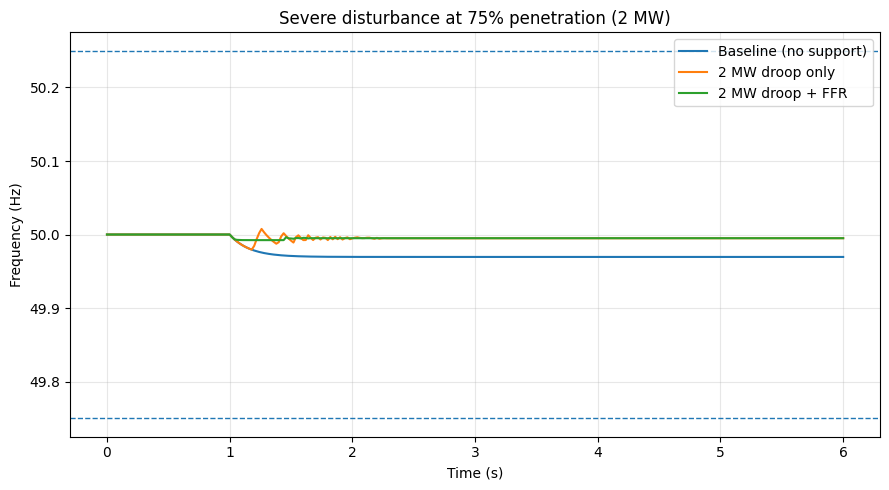

Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\freq_trace_severe_75pct_2MW_openmodelica.png


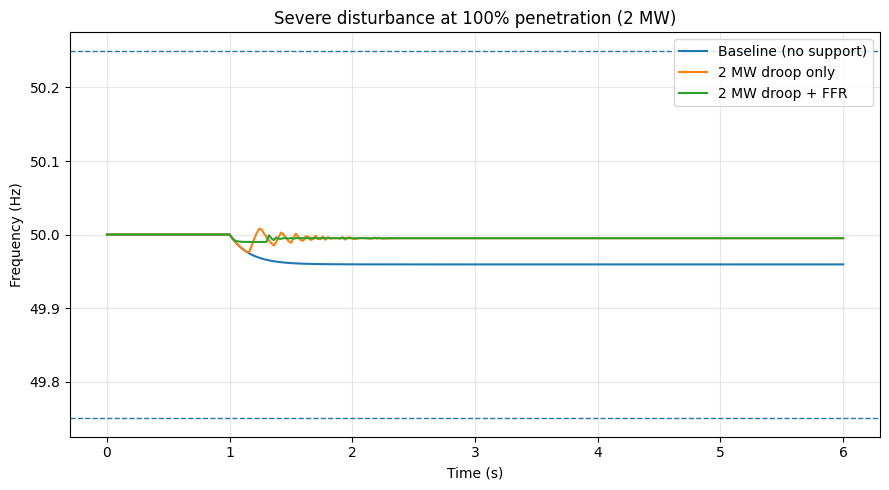

Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\freq_trace_severe_100pct_2MW_openmodelica.png


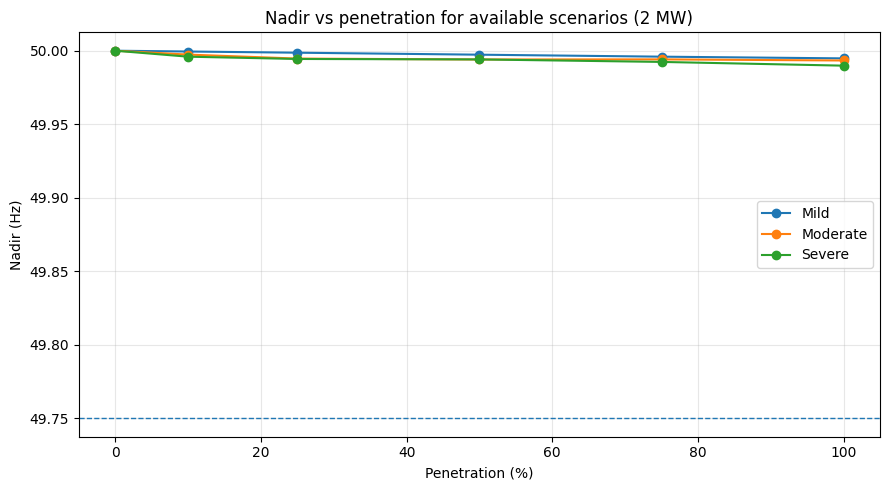

Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\nadir_vs_penetration_2MW_scenarios_openmodelica.png


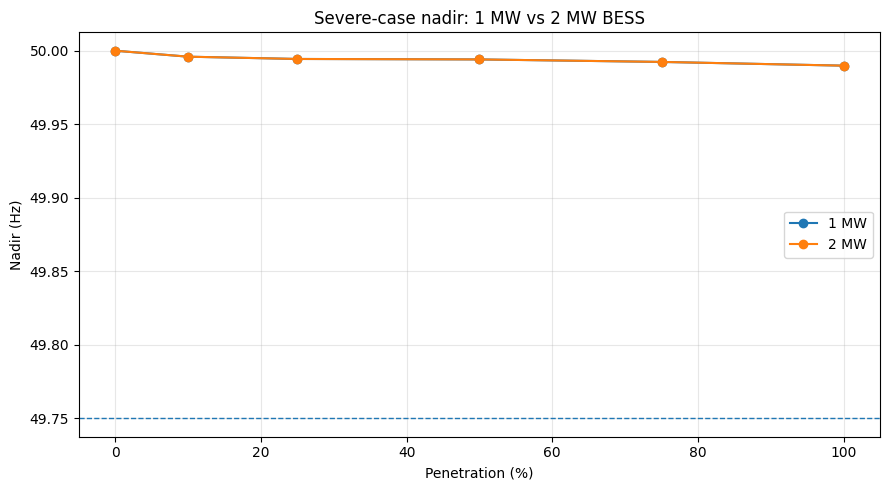

Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\nadir_compare_1MW_vs_2MW_severe_openmodelica.png
results_2mw_df exists? True
size_compare_df exists? True
BESS_2MW exists? True
failures_df exists? True


In [22]:
# =========================================================
# CELL 14: Plot key graphs
# =========================================================
if "results_2mw_df" not in globals() or results_2mw_df.empty:
    raise RuntimeError("results_2mw_df is empty or missing. Run Cell 12 successfully first.")

for pen in [75, 100]:
    plt.figure(figsize=(9, 5))
    plotted = False
    for case_name in support_cases.keys():
        key = (pen, "severe", case_name)
        if key in trace_store:
            sim_df = trace_store[key]
            plt.plot(sim_df["time_s"], sim_df["f_hz"], label=case_name)
            plotted = True
    if not plotted:
        plt.close()
        print(f"Skipping severe trace plot for {pen}% because no traces were stored.")
        continue

    plt.axhline(49.75, linestyle="--", linewidth=1)
    plt.axhline(50.25, linestyle="--", linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Severe disturbance at {pen}% penetration (2 MW)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    out = BASE_DIR / f"freq_trace_severe_{pen}pct_2MW_openmodelica.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

plt.figure(figsize=(9, 5))
plot_df = results_2mw_df[results_2mw_df["Case"] == "2 MW droop + FFR"].copy()
for scen in sorted(plot_df["Scenario"].dropna().unique().tolist()):
    sub = plot_df[plot_df["Scenario"] == scen].sort_values("Penetration (%)")
    if len(sub) > 0:
        plt.plot(sub["Penetration (%)"], sub["Nadir (Hz)"], marker="o", label=str(scen).capitalize())
plt.axhline(49.75, linestyle="--", linewidth=1)
plt.xlabel("Penetration (%)")
plt.ylabel("Nadir (Hz)")
plt.title("Nadir vs penetration for available scenarios (2 MW)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
out = BASE_DIR / "nadir_vs_penetration_2MW_scenarios_openmodelica.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out)

if "size_compare_df" in globals() and not size_compare_df.empty:
    plt.figure(figsize=(9, 5))
    for bess_mw in sorted(size_compare_df["BESS (MW)"].dropna().unique().tolist()):
        sub = size_compare_df[size_compare_df["BESS (MW)"] == bess_mw].sort_values("Penetration (%)")
        plt.plot(sub["Penetration (%)"], sub["Nadir (Hz)"], marker="o", label=f"{int(bess_mw)} MW")
    plt.axhline(49.75, linestyle="--", linewidth=1)
    plt.xlabel("Penetration (%)")
    plt.ylabel("Nadir (Hz)")
    plt.title("Severe-case nadir: 1 MW vs 2 MW BESS")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    out = BASE_DIR / "nadir_compare_1MW_vs_2MW_severe_openmodelica.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)
else:
    print("Skipping 1 MW vs 2 MW plot because size_compare_df is empty or missing.")


print("results_2mw_df exists?", "results_2mw_df" in globals())
print("size_compare_df exists?", "size_compare_df" in globals())
print("BESS_2MW exists?", "BESS_2MW" in globals())
print("failures_df exists?", "failures_df" in globals())


## CELL 15: Save manuscript-ready tables and notes


In [23]:
# =========================================================
# CELL 15: Save manuscript-ready tables and notes
# =========================================================
if "results_2mw_df" not in globals() or results_2mw_df.empty:
    raise RuntimeError("results_2mw_df is not available. Run Cell 12 successfully first.")

table_main = results_2mw_df[
    (results_2mw_df["Scenario"] == "severe") &
    (results_2mw_df["Case"] == "2 MW droop + FFR")
].sort_values("Penetration (%)").reset_index(drop=True)

table_100 = results_2mw_df[
    (results_2mw_df["Penetration (%)"] == 100) &
    (results_2mw_df["Case"] == "2 MW droop + FFR")
].sort_values("Scenario").reset_index(drop=True)

table_main.to_csv(BASE_DIR / "table_main_severe_2MW_openmodelica.csv", index=False)
table_100.to_csv(BASE_DIR / "table_100pct_scenario_comparison_2MW_openmodelica.csv", index=False)

notes = [
    f"FAST_DEBUG mode: {FAST_DEBUG}",
    f"Penetrations run: {PENETRATIONS}",
    f"Scenarios run: {SCENARIOS}",
    "PowerFactory reruns real hourly profiles for selected penetrations.",
    "OpenModelica reads disturbances extracted from PowerFactory exports.",
    "Dynamic study uses 2 MW BESS plus 1 MW vs 2 MW comparison."
]
with open(BASE_DIR / "run_notes_pf_to_om_2MW.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(notes))

print("Saved:", BASE_DIR / "table_main_severe_2MW_openmodelica.csv")
print("Saved:", BASE_DIR / "table_100pct_scenario_comparison_2MW_openmodelica.csv")
print("Saved:", BASE_DIR / "run_notes_pf_to_om_2MW.txt")
print("Finished.")


Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\table_main_severe_2MW_openmodelica.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\table_100pct_scenario_comparison_2MW_openmodelica.csv
Saved: C:\Users\ADMIN\Desktop\ms-project_pf_to_om_2MW\run_notes_pf_to_om_2MW.txt
Finished.
